In [18]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.decomposition import FastICA
from utils import load_images
import joblib

In [13]:
images, _ = load_images()

In [14]:
images.shape

torch.Size([24075, 25, 25])

In [21]:
train_image_size = 20_000
train_images = images[:train_image_size].flatten(start_dim=1)

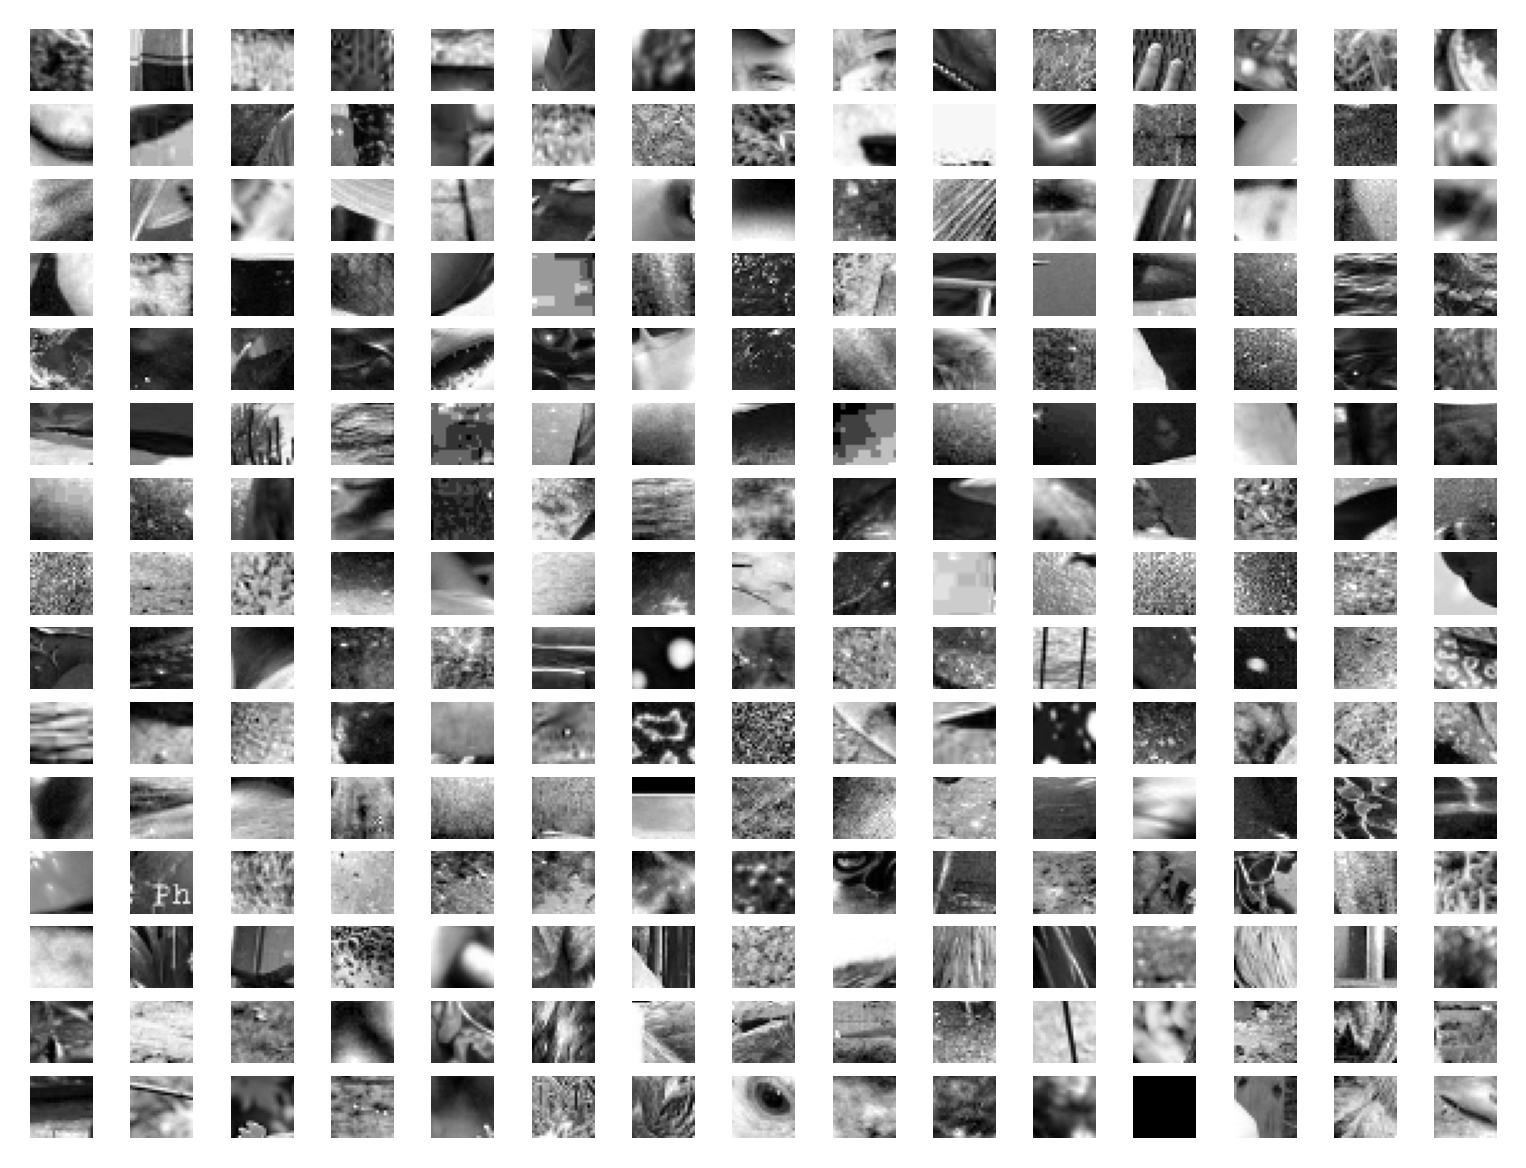

In [22]:
fig, axs = plt.subplots(15, 15, dpi=300)
for i, ax in enumerate(axs.flatten()):
    ax.imshow(train_images[i].reshape(25, 25).squeeze().numpy(), cmap="gray")
    ax.axis("off")
ax.set_aspect("equal")

In [23]:
train_images.shape

torch.Size([20000, 625])

In [24]:
z_dim = 100
transformer = FastICA(n_components=z_dim, random_state=42)
z_train = transformer.fit_transform(train_images)

/usr/local/lib/python3.8/dist-packages/sklearn/decomposition/_fastica.py:542: FutureWarning: Starting in v1.3, whiten='unit-variance' will be used by default.
  warnings.warn(


In [25]:
model_fname = "fastica_25x25_100_logcosh.joblib"
joblib.dump(transformer, model_fname)

['fastica_25x25_100_logcosh.joblib']

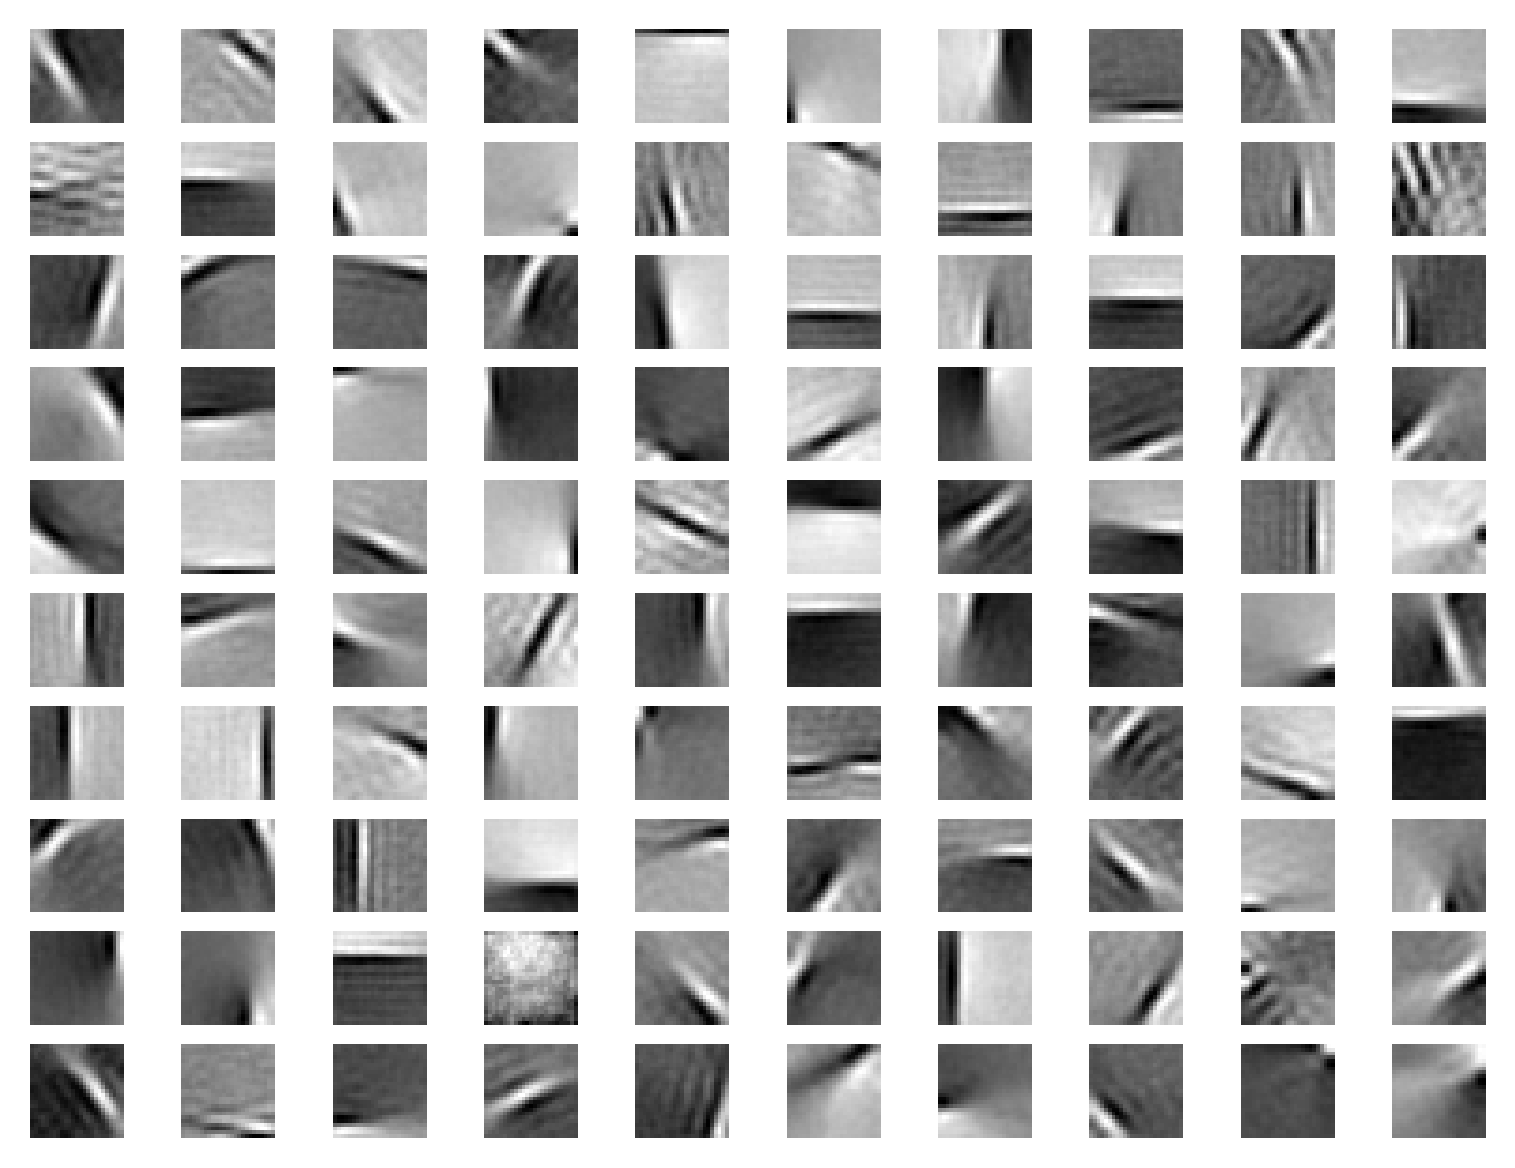

In [26]:
fig, axs = plt.subplots(10, 10, dpi=300)
for i, ax in enumerate(axs.flatten()):
    ax.imshow(transformer.mixing_[:, i].reshape(25, 25).squeeze(), cmap="gray")
    ax.axis("off")
ax.set_aspect("equal")

In [27]:
z = transformer.transform(train_images)

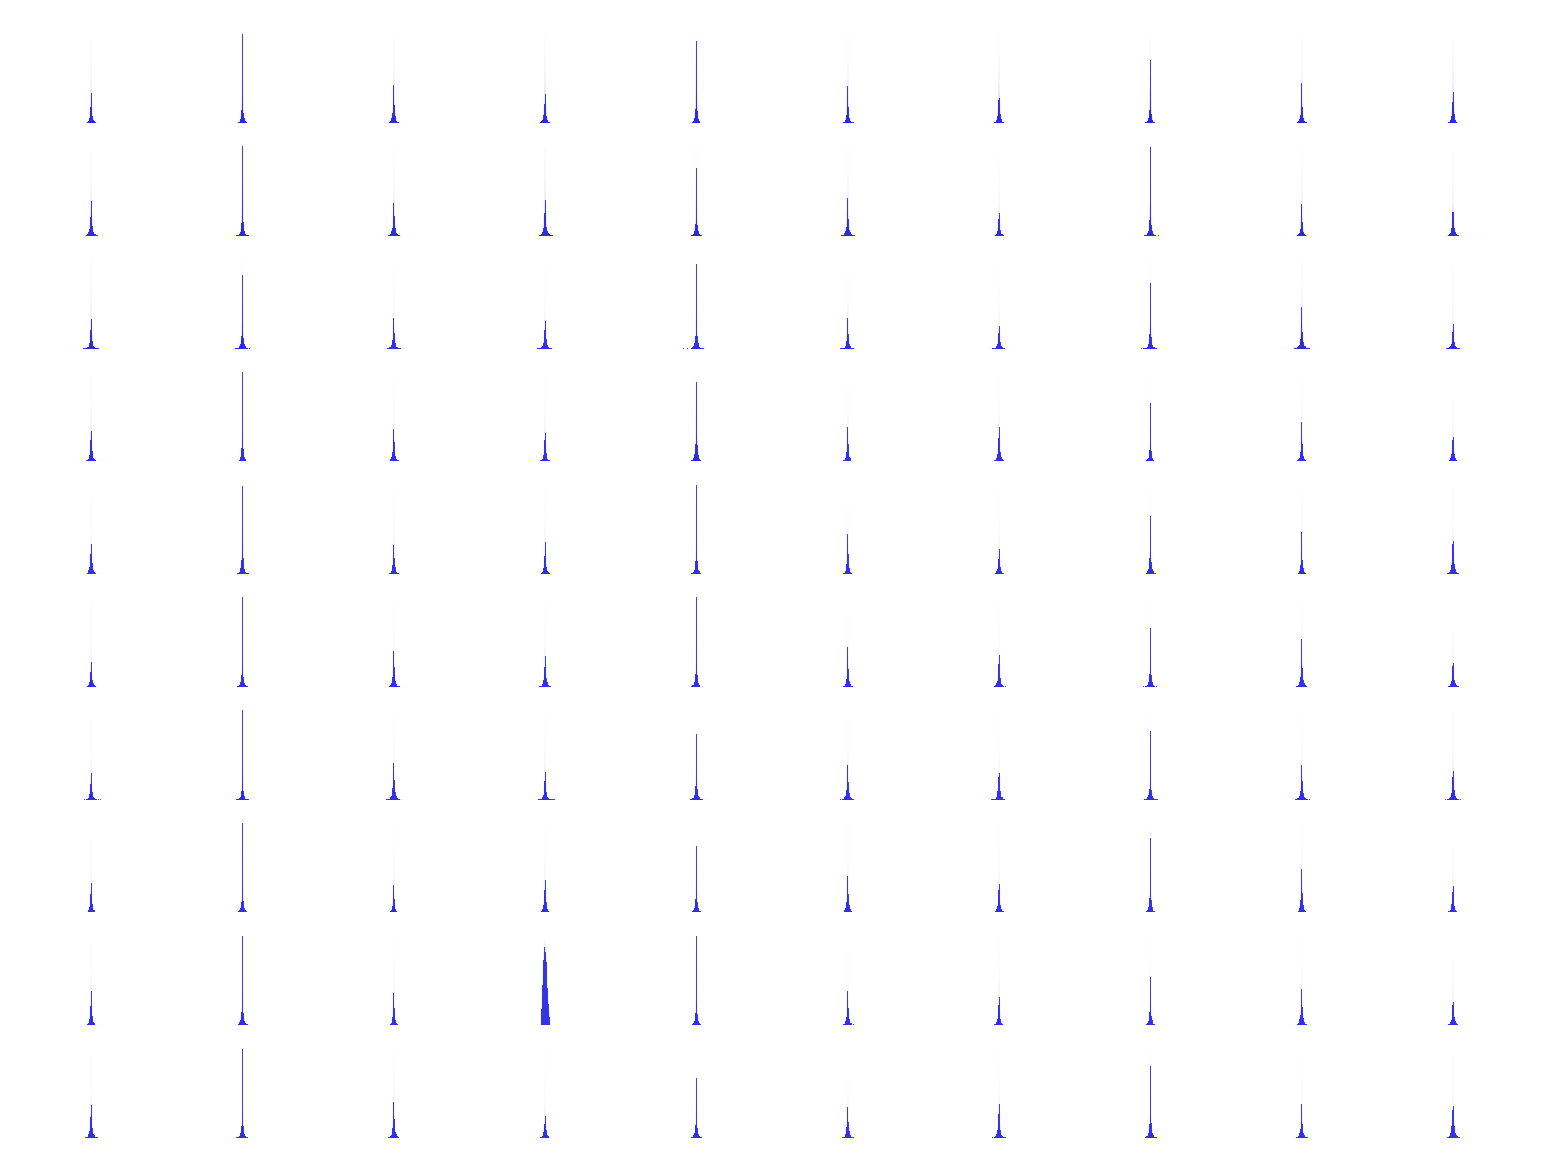

In [28]:
fig, axs = plt.subplots(10, 10, dpi=300, sharex=True)
for values, ax in zip(z.T, axs.flatten()):
    sns.histplot(
        values,
        ax=ax,
        stat="density",
        color="blue",
    )
    ax.axis("off")

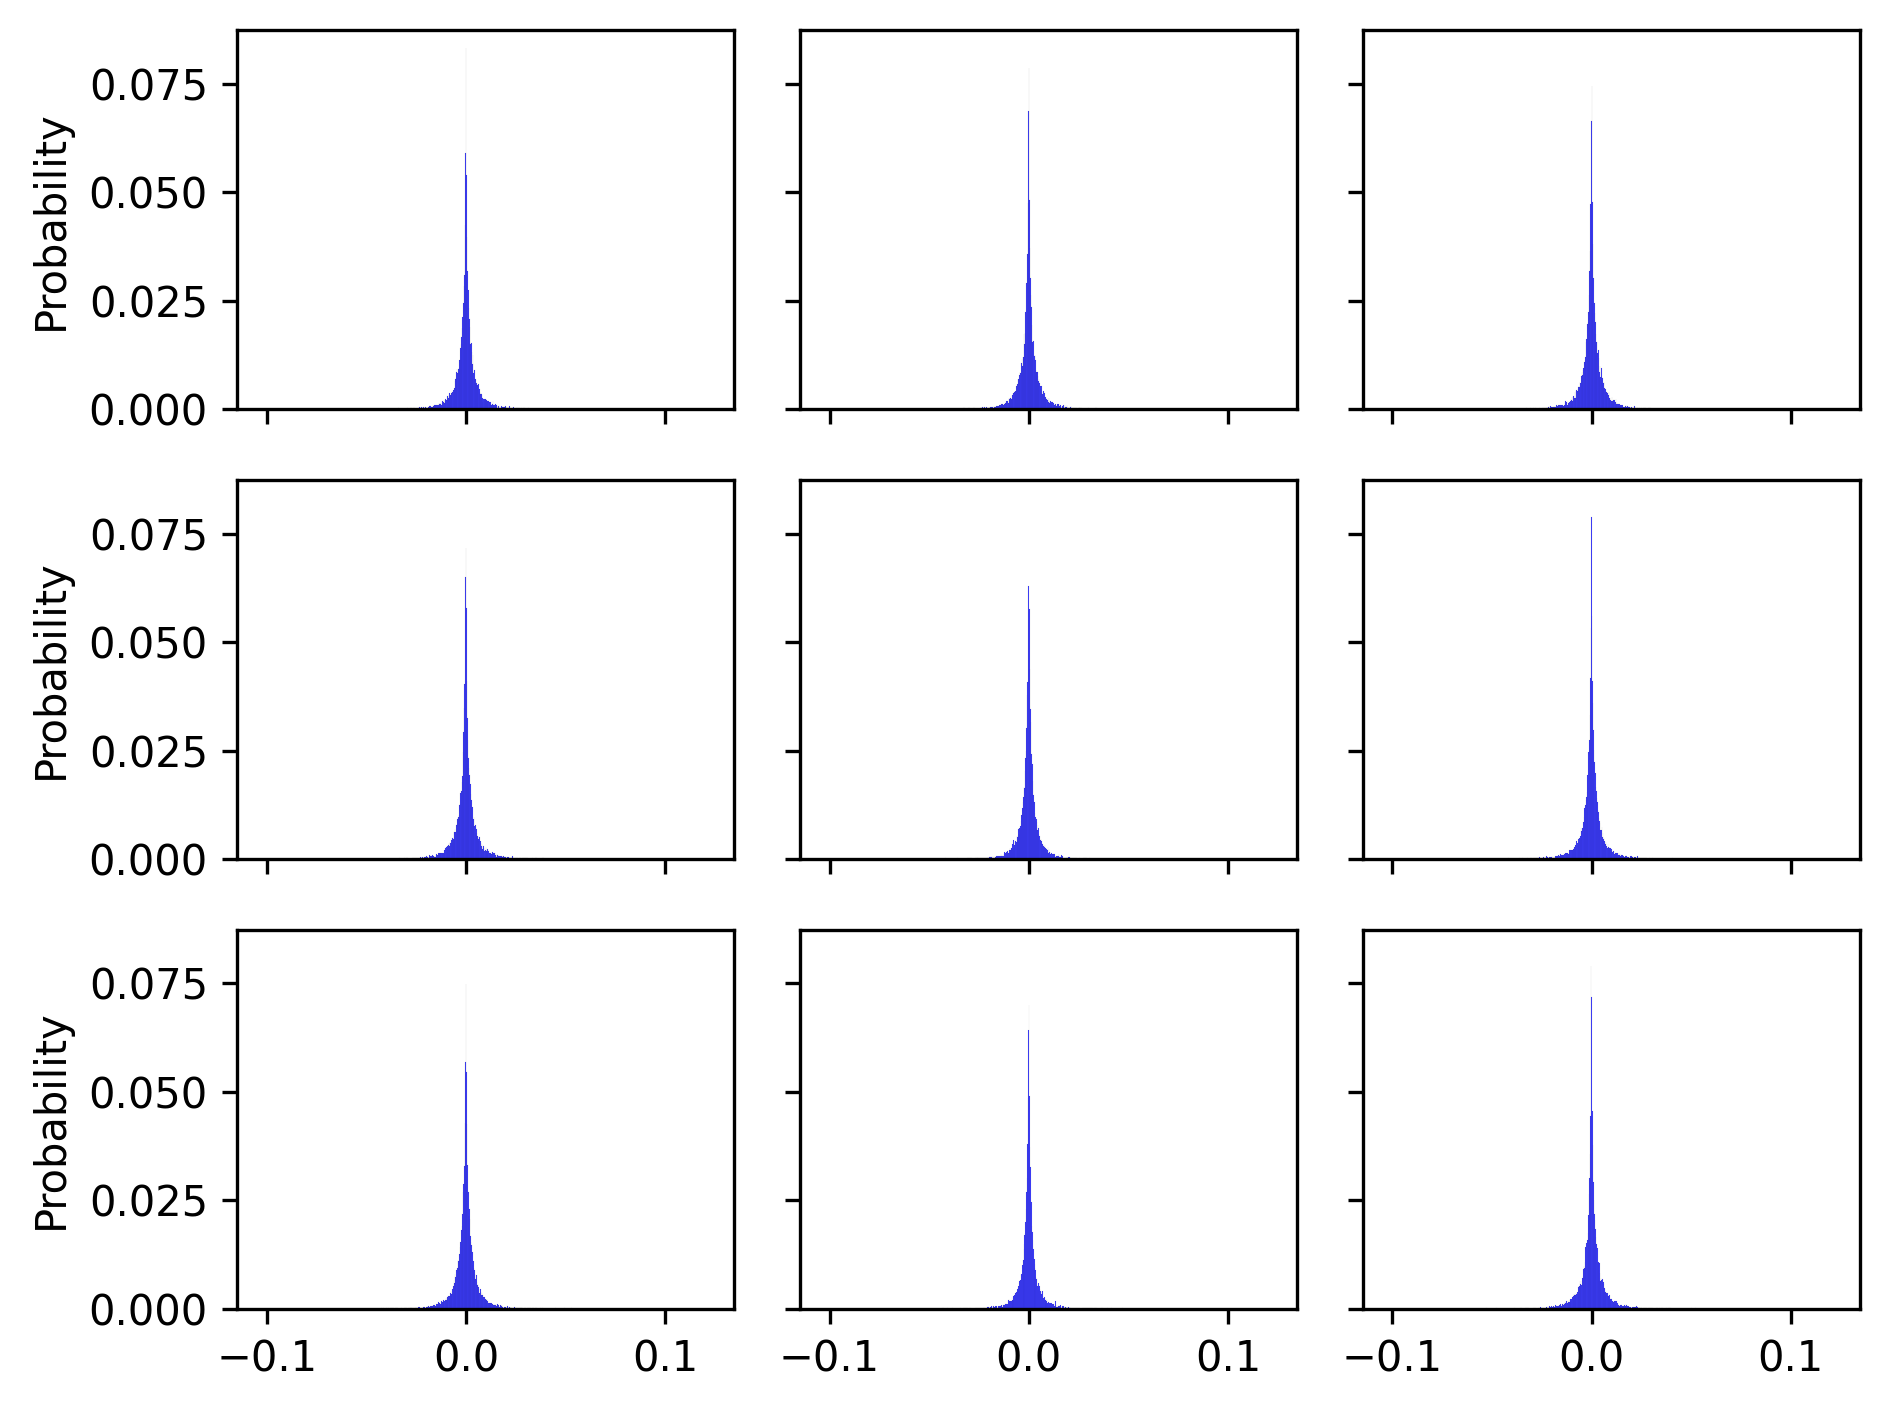

In [29]:
fig, axs = plt.subplots(3, 3, dpi=300, sharex=True, sharey=True, tight_layout=True)
for values, ax in zip(z.T, axs.flatten()):
    sns.histplot(
        values,
        ax=ax,
        stat="probability",
        color="blue",
    )
    # ax.axis("off")